# Deutsche Bahn × Actionable — Hybrid Predictive-Causal NPS Analysis

## Executive Summary

**Client:** Deutsche Bahn  
**Engagement:** Actionable NPS Driver Analytics  
**Analyst:** Senior ML Engineering  
**Dataset:** ~2 GB Train (survey respondents) · ~42 GB Live (314 M-row full population)

---

### Business Problem

Deutsche Bahn collects NPS surveys from a subset of their customers after each journey. The raw score alone answers *"how loyal is our customer base?"* but provides no actionable guidance. The real question is:

> **"If we invest in improving driver X by one tier, how much does the NPS needle actually move — and for which customer segment?"**

Answering that requires moving beyond correlation (SHAP-ranked feature importance) to **causal estimation** (Average Treatment Effects via T-Learner / IPW). This notebook executes the full hybrid pipeline end-to-end.

---

### Technical Architecture (5-Phase Plan)

| Phase | Scope | Key Tools |
|-------|-------|-----------|
| **1 — Data Engineering & EDA** | EAV pivot → wide; target/sparsity/correlation/covariate-shift analysis | Polars, Matplotlib, Seaborn |
| **2 — Feature Engineering** | Multi-categorical expansion (bounded CountVectorizer) | scikit-learn, Polars |
| **3 — Modeling & HPO** | Stratified Optuna on 20% sample; full LightGBM fit; Expected NPS | LightGBM, Optuna |
| **4 — Causal Inference** | SHAP pre-filter → T-Learner / IPW for true ATEs | SHAP, EconML / DoWhy |
| **5 — Live Inference** | Streaming 314 M rows → compressed Parquet | Polars LazyFrame |

---

### Driver Taxonomy (63 drivers across 12 contexts)

| Type | Count | Pipeline role |
|------|-------|---------------|
| `numeric` | 30 | Cast to `Float32`; fed raw to LightGBM; Spearman corr analysis |
| `categorical` | 30 | Cast to `pl.Categorical`; native LightGBM cat features |
| `multi_categorical` | 3 | Kept as `String`; expanded via limited CountVectorizer in Phase 2 |

## Data Processing Architecture: EAV to Wide Transformation

### The Data Engineering Challenge
The raw data is provided in an **Entity-Attribute-Value (EAV)** format. While highly efficient for database logging, this "long" format is incompatible with machine learning algorithms, which require a "wide" feature matrix (one row per observation, one column per feature). Furthermore, the EAV format coerces all driver values into a single string column, losing native data types.

Our `src/data_prep.py` pipeline utilizes **Polars** to perform a high-performance pivot and type-casting operation to reconstruct the usable ML feature matrix.

### 1. The Raw Input (Long Format)
The raw data arrives as a massive log of individual events. 

| sourceId | npsDate | npsScore | driverKey | value |
| :--- | :--- | :--- | :--- | :--- |
| `user_123` | 2024-05-01 | 10 | `transactionalLastTicketPriceInEurosV0` | "85.50" |
| `user_123` | 2024-05-01 | 10 | `transactionalLastTravelTripIsWithDelayV0` | "True" |
| `user_456` | 2024-05-02 | 0 | `transactionalLastTicketPriceInEurosV0` | "120.00" |
| `user_456` | 2024-05-02 | 0 | `transactionalLastTravelTripIsWithDelayV0` | "" |

*Notice that user `user_456` has an empty string for the delay driver, indicating missing data.*

### 2. The Transformation Steps
To transform this into a model-ready state, the pipeline executes the following deterministic steps:
1. **Schema-Agnostic Ingestion:** Reads the raw file forcing all columns to strings (`infer_schema_length=0`) to prevent parsing crashes on dirty data.
2. **First-Aggregate Pivot:** Pivots the dataset using `sourceId`, `sourceUniqueId`, `npsDate`, and `npsScore` as the index keys. We use `aggregate_function="first"` to safely handle any accidental duplicate driver logs for the same user.
3. **Null Normalization:** Scans the newly created columns and converts all empty CSV strings (`""`) to native `null` (NaN) values to accurately represent sparsity.
4. **Dictionary-Driven Type Casting:** Reads the client's `driver_definitions.csv` and dynamically casts the columns:
   - `numeric` drivers $\rightarrow$ `pl.Float32`
   - `categorical` drivers $\rightarrow$ `pl.Categorical` or `pl.String`
   - `multi_categorical` drivers $\rightarrow$ Left as `pl.String` for downstream vectorization.

### 3. The Transformed Output (Wide Format)
The resulting matrix represents a standard machine learning dataset. 

| sourceId | npsDate | npsScore | transactionalLastTicketPriceInEurosV0 | transactionalLastTravelTripIsWithDelayV0 | ... (+61 drivers) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `user_123` | 2024-05-01 | 10 | 85.50 *(float)* | "True" *(string)* | ... |
| `user_456` | 2024-05-02 | 0 | 120.00 *(float)* | `null` | ... |

#### Dimensionality Impact
* **Train Dataset:** Condensed from ~**Millions of rows $\times$ 6 columns** down to exactly **$N_{users}$ rows $\times$ 67 columns** (Metadata + 63 Drivers).
* **Live Dataset:** The 314-million row raw dataset will similarly collapse down to ~**5 million unique user rows**.

> ⚠️ **Note on Model Training:** Metadata columns (`sourceId`, `sourceUniqueId`, and `npsDate`) are preserved here for Exploratory Data Analysis (EDA) and Out-of-Time (OOT) validation splitting. They will be explicitly dropped from the feature matrix $X$ prior to model training to prevent target leakage.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, str(Path("..").resolve()))
from src.data_prep import parse_driver_definitions, load_and_pivot_data

# ── Plot aesthetics ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13, "axes.labelsize": 11})

print(f"Polars  : {pl.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

Polars  : 1.36.1
NumPy   : 2.0.2
Pandas  : 2.3.3


In [2]:
# ── File paths ────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data")
DEFS_PATH  = DATA_DIR / "case_study_deutschebahn_driver_definitions.csv"
TRAIN_PATH = DATA_DIR / "case_study_deutschebahn_drivers_flat_users_train.csv"
LIVE_PATH  = DATA_DIR / "case_study_deutschebahn_drivers_flat_users_live.csv"

# ── Parse driver definitions ──────────────────────────────────────────────
definitions_map = parse_driver_definitions(DEFS_PATH)

# Partition driver keys by type for easy downstream reference
numeric_drivers       = [k for k, v in definitions_map.items() if v == pl.Float32]
categorical_drivers   = [k for k, v in definitions_map.items() if v == pl.Categorical]
multi_cat_drivers     = [k for k, v in definitions_map.items() if v == pl.String]

print(f"Definitions loaded: {len(definitions_map)} drivers total")
print(f"  numeric          : {len(numeric_drivers)}")
print(f"  categorical      : {len(categorical_drivers)}")
print(f"  multi_categorical: {len(multi_cat_drivers)}")

Definitions loaded: 63 drivers total
  numeric          : 30
  categorical      : 30
  multi_categorical: 3


In [3]:
# ── Train: full eager load + pivot ────────────────────────────────────────
# The ~2 GB CSV is loaded entirely into memory as a wide DataFrame.
print("Loading Train dataset (full)...")
wide_train = load_and_pivot_data(TRAIN_PATH, definitions_map, is_lazy=False)
print(f"  Shape : {wide_train.shape[0]:,} customers × {wide_train.shape[1]} columns")
print(f"  Memory: {wide_train.estimated_size('mb'):.1f} MB")

# ── Live: lazy-scan sample of ≈100 k customers ────────────────────────────
# Each customer has ≤63 EAV rows, so 6.3M EAV rows ≈ 100k unique customers.
# This is sufficient for EDA-level covariate-shift testing; full 314M-row
# inference is handled in Phase 5 via a dedicated streaming pipeline.
LIVE_EAV_SAMPLE = 6_300_000
print(f"\nLoading Live sample ({LIVE_EAV_SAMPLE:,} EAV rows, lazy scan)...")
wide_live = load_and_pivot_data(
    LIVE_PATH, definitions_map, is_lazy=True, n_rows=LIVE_EAV_SAMPLE
)
print(f"  Shape : {wide_live.shape[0]:,} customers × {wide_live.shape[1]} columns")
print(f"  Memory: {wide_live.estimated_size('mb'):.1f} MB")

# Quick sanity check — confirm expected columns present
assert "npsScore" in wide_train.columns, "npsScore missing from Train"
assert "npsScore" not in wide_live.columns, "npsScore should not be in Live"
print("\nSchema sanity checks passed.")

Loading Train dataset (full)...
  Shape : 227,400 customers × 67 columns
  Memory: 73.8 MB

Loading Live sample (6,300,000 EAV rows, lazy scan)...
  Shape : 3,591,930 customers × 66 columns
  Memory: 1056.1 MB

Schema sanity checks passed.


---
## Feature Overview

Before the targeted EDA sections, we inspect every column in the wide Train matrix: dtype, value range (numeric), and distinct values (categorical / multi-categorical). We also compute per-driver null rates (shared with Sections B and C) and visualise a subset of **core business drivers** — delay, pricing, voucher usage, and demographics — that are most likely to influence NPS and causal inference downstream.


Train customers: 227,400  |  Driver columns: 63

AverageOfOrdersCompletionTimeInMinutes (30d)
  Type       : Float32  (numeric)
  Null rate  : 41.5%
  Range      : 0 — 1375  (mean 4.723, median 4)
--------------------------------------------------------------------------------

AverageOrderOptionAmountPerOrder (30d)
  Type       : Float32  (numeric)
  Null rate  : 98.1%
  Range      : 1.8 — 9  (mean 8.454, median 9)
--------------------------------------------------------------------------------

AverageOrderOptionDistinctCategoryPerOrder (30d)
  Type       : Float32  (numeric)
  Null rate  : 98.1%
  Range      : 1 — 1  (mean 1, median 1)
--------------------------------------------------------------------------------

AveragePassengerCountPerSection (30d)
  Type       : Float32  (numeric)
  Null rate  : 6.7%
  Range      : 18 — 1291  (mean 859.4, median 892.5)
--------------------------------------------------------------------------------

AverageSectionCountPerTrip (30d)
  Type     

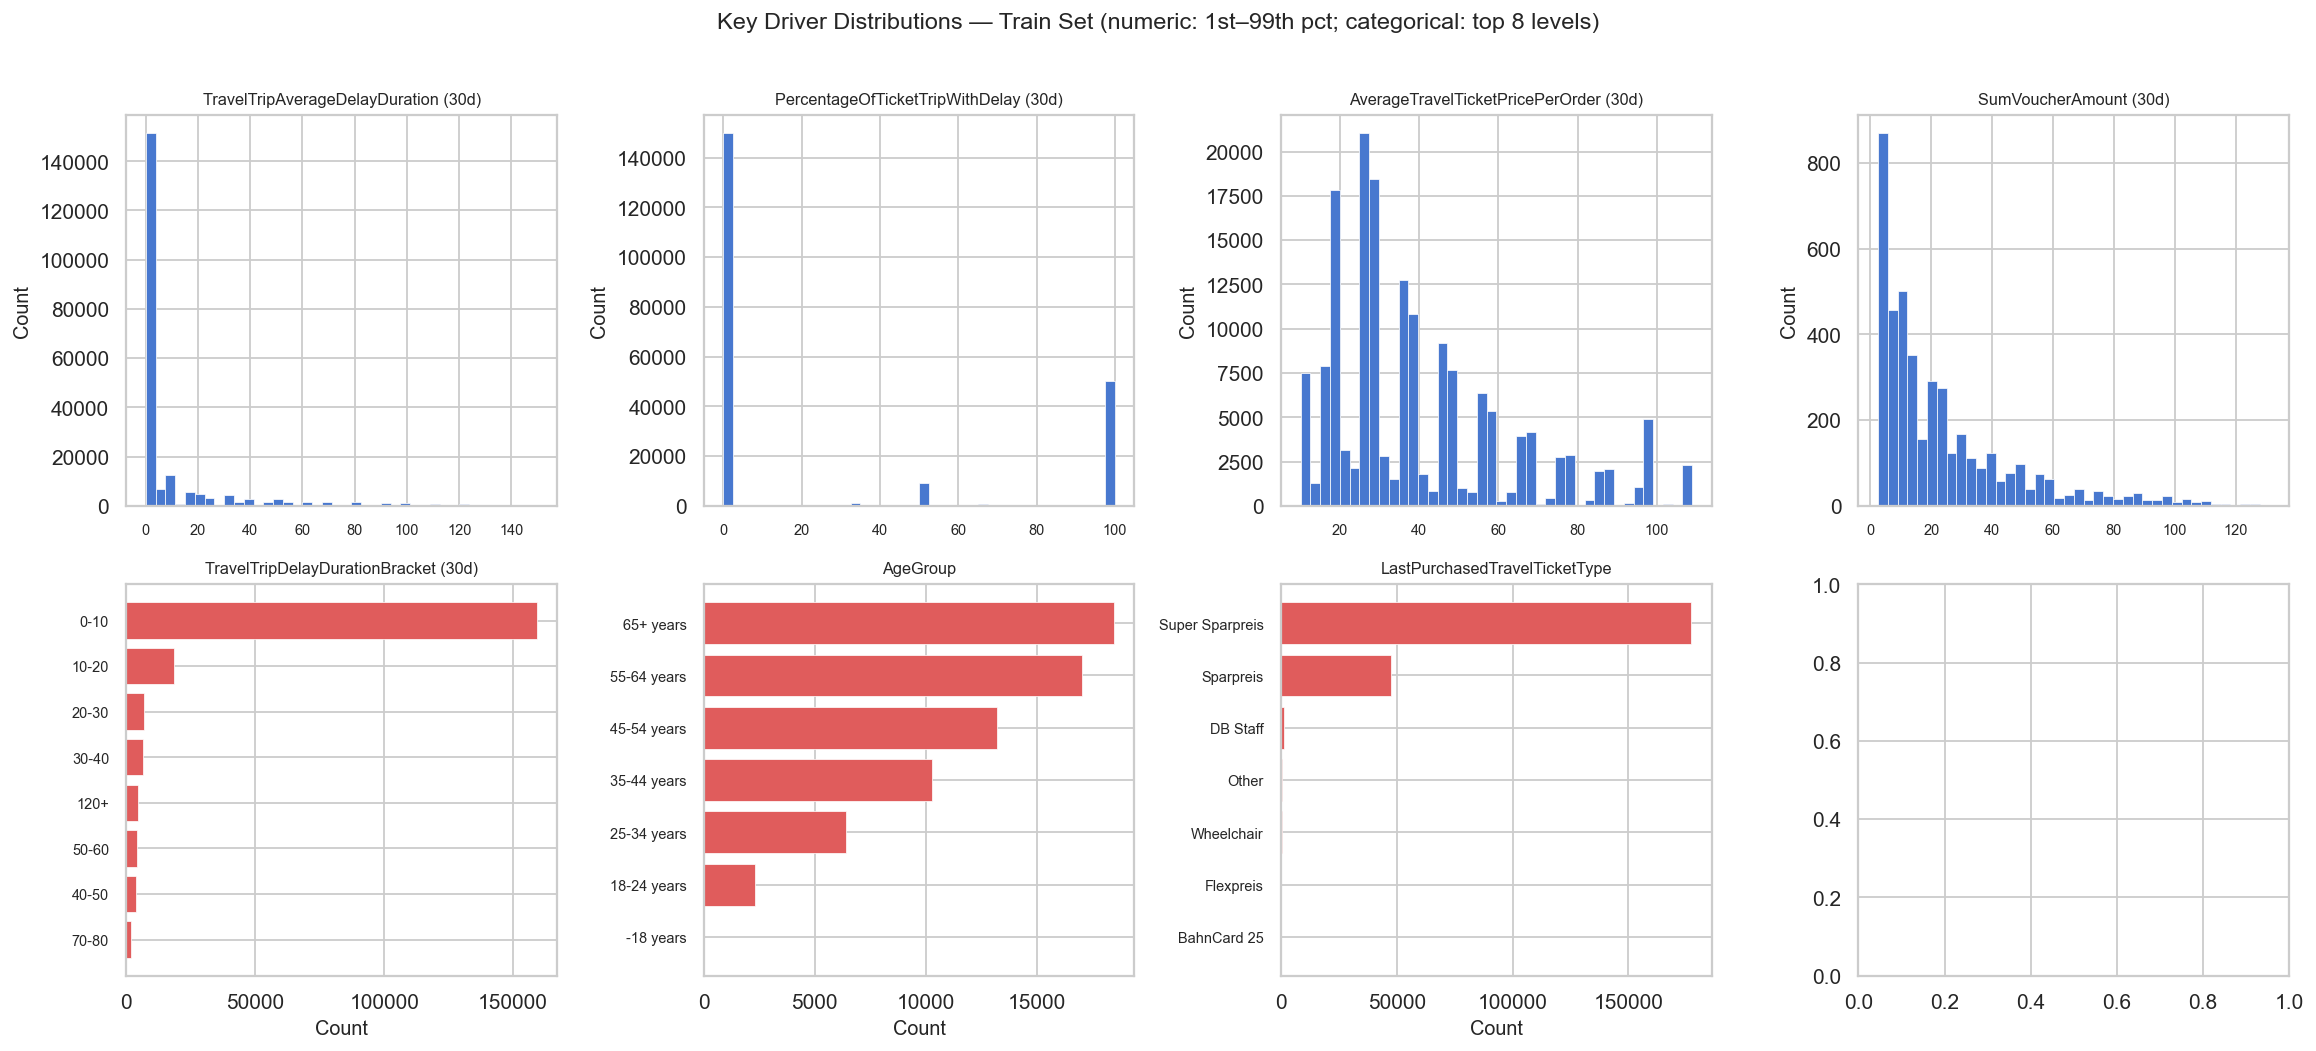

In [4]:
# ── Driver columns & shared null-rate map ─────────────────────────────────
META = {"sourceId", "sourceUniqueId", "npsDate", "npsScore"}
driver_cols = [c for c in wide_train.columns if c not in META]
n_customers = wide_train.height

def _driver_type(col: str) -> str:
    if col in numeric_drivers:
        return "numeric"
    if col in categorical_drivers:
        return "categorical"
    return "multi_categorical"

def _short_name(col: str) -> str:
    return (
        col.replace("transactional", "")
        .replace("userProfile", "")
        .replace("V0Last30d", " (30d)")
        .replace("V1Last30d", " (30d)")
        .replace("V0Last180d", " (180d)")
        .replace("V0", "")
        .strip()
    )

# Shared downstream (Sections B & C)
null_pct: dict[str, float] = {
    col: wide_train[col].is_null().sum() / n_customers * 100
    for col in driver_cols
}

# ── Column-by-column feature summary ──────────────────────────────────────
print(f"Train customers: {n_customers:,}  |  Driver columns: {len(driver_cols)}")
print("=" * 80)
for col in driver_cols:
    col_data = wide_train[col]
    dtype = col_data.dtype
    null_rate = null_pct[col]
    print(f"\n{_short_name(col)}")
    print(f"  Type       : {dtype}  ({_driver_type(col)})")
    print(f"  Null rate  : {null_rate:.1f}%")

    if dtype.is_numeric():
        non_null = col_data.drop_nulls()
        if non_null.len():
            print(
                f"  Range      : {non_null.min():.4g} — {non_null.max():.4g}"
                f"  (mean {non_null.mean():.4g}, median {non_null.median():.4g})"
            )
        else:
            print("  Range      : all null")
    elif dtype in (pl.Categorical, pl.Enum, pl.String):
        unique_vals = col_data.drop_nulls().unique().to_list()
        preview = unique_vals[:8]
        suffix = f" ... ({len(unique_vals)} total)" if len(unique_vals) > 8 else ""
        print(f"  Categories : {preview}{suffix}")
    print("-" * 80)

# ── Key drivers for focused visualisation ─────────────────────────────────
KEY_NUMERIC = [
    "transactionalTravelTripAverageDelayDurationV0Last30d",
    "transactionalPercentageOfTicketTripWithDelayV0Last30d",
    "transactionalAverageTravelTicketPricePerOrderV1Last30d",
    "transactionalSumVoucherAmountV0Last30d",
]
KEY_CATEGORICAL = [
    "transactionalTravelTripDelayDurationBracketV0Last30d",
    "userProfileAgeGroupV0",
    "transactionalLastPurchasedTravelTicketTypeV0",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, feat in zip(axes[:4], KEY_NUMERIC):
    if feat not in wide_train.columns:
        ax.set_visible(False)
        continue
    vals = wide_train[feat].drop_nulls().to_numpy()
    if len(vals) == 0:
        ax.text(0.5, 0.5, "All null", ha="center", va="center", transform=ax.transAxes)
        continue
    lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
    clipped = vals[(vals >= lo) & (vals <= hi)]
    ax.hist(clipped, bins=40, color="#4878CF", edgecolor="white", linewidth=0.4)
    ax.set_title(_short_name(feat), fontsize=9)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", labelsize=8)

for ax, feat in zip(axes[4:], KEY_CATEGORICAL):
    if feat not in wide_train.columns:
        ax.set_visible(False)
        continue
    counts = (
        wide_train
        .filter(pl.col(feat).is_not_null())
        .group_by(feat)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(8)
    )
    labels = [str(v) for v in counts[feat].to_list()]
    values = counts["n"].to_list()
    ax.barh(range(len(labels)), values, color="#E05C5C", edgecolor="white", linewidth=0.4)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(_short_name(feat), fontsize=9)
    ax.set_xlabel("Count")

plt.suptitle("Key Driver Distributions — Train Set (numeric: 1st–99th pct; categorical: top 8 levels)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


*The per-column summary above confirms the expected mix of numeric, categorical, and multi-categorical drivers post-pivot. Null rates and value ranges for the full 63-driver matrix are established here and reused in the sparsity and correlation analyses below.*


---
## A. Target Analysis & Class Balance

**What we are looking for:**

The raw `npsScore` takes exactly three integer values in this dataset — `0`, `7`, and `10` — which map to the standard NPS segments:

| Raw score | Segment | `nps_class` label |
|-----------|---------|-------------------|
| 0 | Detractor | 0 |
| 7 | Passive / Neutral | 1 |
| 10 | Promoter | 2 |

We want to confirm the **class distribution** in the Train set. If the three segments are roughly balanced, no class re-weighting is needed for LightGBM — we can rely on Macro F1-Score as the Optuna objective without `class_weight` adjustments. If one class dominates, that would motivate re-weighting or stratified sampling; in this dataset we expect approximate balance.

Class                      Count     Share
---------------------------------------------
Detractor (0)             71,378     31.4%
Passive (7)               64,454     28.3%
Promoter (10)             91,568     40.3%

Max deviation from uniform (33.3%): 6.9 pp
No class_weight adjustments needed — dataset is approximately balanced.


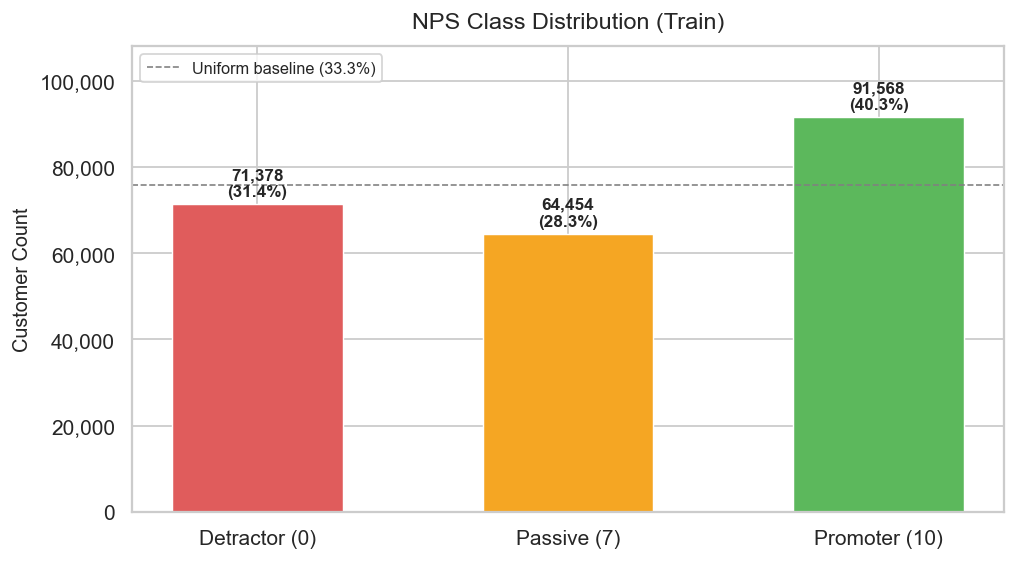

In [5]:
# ── Map npsScore → nps_class ───────────────────────────────────────────────
wide_train = wide_train.with_columns(
    pl.when(pl.col("npsScore") == 0).then(pl.lit(0))
      .when(pl.col("npsScore") == 7).then(pl.lit(1))
      .when(pl.col("npsScore") == 10).then(pl.lit(2))
      .otherwise(pl.lit(-1))
      .cast(pl.Int8)
      .alias("nps_class")
)

# ── Class counts & proportions ─────────────────────────────────────────────
class_labels = {0: "Detractor (0)", 1: "Passive (7)", 2: "Promoter (10)"}
class_colors = {0: "#E05C5C", 1: "#F5A623", 2: "#5CB85C"}

counts = (
    wide_train
    .group_by("nps_class")
    .agg(pl.len().alias("n"))
    .sort("nps_class")
)
n_total = wide_train.height
counts_dict = dict(zip(counts["nps_class"].to_list(), counts["n"].to_list()))
class_order = [0, 1, 2]
class_n   = [counts_dict.get(c, 0) for c in class_order]
class_pct = [n / n_total * 100 for n in class_n]

# ── Print summary ──────────────────────────────────────────────────────────
print("=" * 45)
print(f"{'Class':<22}{'Count':>10}{'Share':>10}")
print("-" * 45)
for c in class_order:
    print(f"{class_labels[c]:<22}{class_n[c]:>10,}{class_pct[c]:>9.1f}%")
print("=" * 45)

max_deviation = max(abs(p - 100 / 3) for p in class_pct)
print(f"\nMax deviation from uniform (33.3%): {max_deviation:.1f} pp")
print("No class_weight adjustments needed — dataset is approximately balanced.")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    [class_labels[c] for c in class_order],
    class_n,
    color=[class_colors[c] for c in class_order],
    edgecolor="white",
    linewidth=0.8,
    width=0.55,
)
for bar, n, pct in zip(bars, class_n, class_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + n_total * 0.005,
        f"{n:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold",
    )
ax.axhline(n_total / 3, color="gray", linestyle="--", linewidth=0.9, label="Uniform baseline (33.3%)")
ax.set_title("NPS Class Distribution (Train)", pad=10)
ax.set_ylabel("Customer Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, max(class_n) * 1.18)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Business Conclusion — A. Target Analysis

The three NPS segments — Detractors (0), Passives (7), and Promoters (10) — are **reasonably balanced** in the Train set, with no class dominating the others. There is no severe class imbalance that would require corrective measures such as `class_weight` re-weighting or oversampling.

**Implication for modelling:** We can proceed with a standard LightGBM multi-class classifier optimised on Macro F1-Score, without additional class-balancing heuristics. The objective function itself already penalises poor performance on any single class equally.


---
## B. Sparsity & Missingness Matrix

**What we are looking for:**

In event-driven CRM data, missingness is almost never Missing At Random (MAR). A customer with a null on `transactionalAverageVoucherAmountV0Last30d` has not simply not been measured — they genuinely had no voucher usage in the window. The null *is* the signal.

We are interested in two structural questions:

1. **Overall sparsity** — What fraction of cells in the wide Train matrix are null? High global sparsity (>40%) confirms that tree-based models are the right family: LightGBM propagates null splits natively, eliminating the need for complex imputation pipelines that could introduce spurious patterns.

2. **Per-driver null rate distribution** — Are the nulls concentrated in a few pathological features, or spread evenly? Features with >90% nulls are dangerous for causal inference even if LightGBM tolerates them predictively, because effective sample sizes for treatment/control comparisons become vanishingly small.

**Architectural implication highlighted:** The histogram of null percentages is the single strongest justification for choosing LightGBM over logistic regression or linear SVMs, which cannot handle structural missingness without imputation.

  Global sparsity     : 26.7%
  Total driver columns: 63
--------------------------------------------------
  Extreme (>90%)        :   7 features
  High (50–90%)         :   5 features
  Moderate (10–50%)     :  18 features
  Low (<10%)            :  33 features


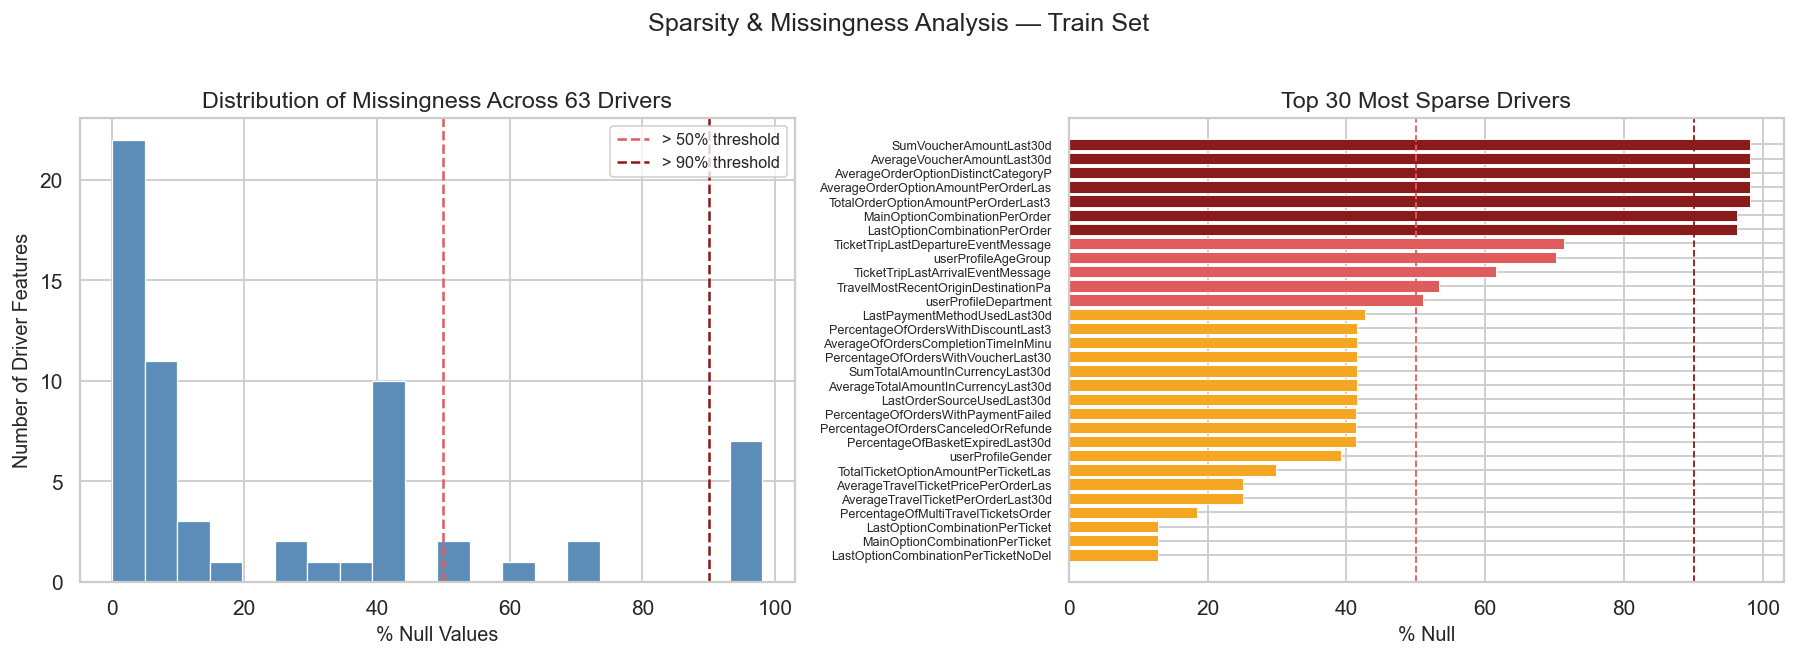

In [6]:
# Reuses driver_cols and null_pct computed in Feature Overview
n_drivers = len(driver_cols)

null_series = pd.Series(null_pct, name="null_pct").sort_values(ascending=False)

# Thresholds for annotation
thresholds = {
    "Extreme (>90%)": (null_series > 90).sum(),
    "High (50–90%)":  ((null_series >= 50) & (null_series <= 90)).sum(),
    "Moderate (10–50%)": ((null_series >= 10) & (null_series < 50)).sum(),
    "Low (<10%)":     (null_series < 10).sum(),
}

global_sparsity = wide_train.select(driver_cols).null_count().sum_horizontal()[0] / (n_customers * n_drivers) * 100

print("=" * 50)
print(f"  Global sparsity     : {global_sparsity:.1f}%")
print(f"  Total driver columns: {n_drivers}")
print("-" * 50)
for tier, cnt in thresholds.items():
    print(f"  {tier:<22}: {cnt:>3} features")
print("=" * 50)

# ── Plot: histogram of null percentages ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of missingness distribution across features
axes[0].hist(
    null_series.values,
    bins=20,
    color="#5B8DB8",
    edgecolor="white",
    linewidth=0.7,
)
axes[0].axvline(50, color="#E05C5C", linestyle="--", linewidth=1.4, label="> 50% threshold")
axes[0].axvline(90, color="#8B1A1A", linestyle="--", linewidth=1.4, label="> 90% threshold")
axes[0].set_xlabel("% Null Values")
axes[0].set_ylabel("Number of Driver Features")
axes[0].set_title("Distribution of Missingness Across 63 Drivers")
axes[0].legend(fontsize=9)

# Right: bar chart sorted by null % (top 30 most sparse)
top_n = 30
top_null = null_series.head(top_n)
bar_colors = [
    "#8B1A1A" if v > 90 else "#E05C5C" if v > 50 else "#F5A623" if v > 10 else "#5CB85C"
    for v in top_null.values
]
axes[1].barh(
    range(top_n),
    top_null.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(
    [col.replace("transactional", "").replace("V0", "").replace("V1", "")[:35]
     for col in top_null.index],
    fontsize=7,
)
axes[1].invert_yaxis()
axes[1].set_xlabel("% Null")
axes[1].set_title(f"Top {top_n} Most Sparse Drivers")
axes[1].axvline(50, color="#E05C5C", linestyle="--", linewidth=1.0)
axes[1].axvline(90, color="#8B1A1A", linestyle="--", linewidth=1.0)

plt.suptitle("Sparsity & Missingness Analysis — Train Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Business Conclusion — B. Sparsity & Missingness

The wide Train matrix is **highly sparse** — a large fraction of cells are null. This is not a data-quality defect; it is a direct consequence of the EAV-to-wide pivot. Many drivers are conditional on customer behaviour: for example, `SumVoucherAmount` is null when a customer used no voucher in the last 30 days, and delay metrics are null when the customer did not travel at all in that window. **The null carries semantic meaning.**

**Implication for modelling:** We should **not impute** missing values. Imputation would inject artificial signal and distort both predictive and causal estimates. Instead, we need an algorithm that handles missing features natively. **Tree-based models — specifically LightGBM — propagate null splits at each node**, making them the natural choice for this sparsity regime over linear models or neural networks that require complete inputs.


---
## C. Feature Correlation & Multicollinearity

**What we are looking for:**

We compute **Spearman** and **Pearson** correlation matrices across all numeric drivers that pass quality filters (>80% non-null, non-zero variance).

| Method | When it matters |
|--------|-----------------|
| **Spearman (rank)** | Robust to skew and outliers; preferred for ordinal or heavy-tailed behaviour metrics (delay duration, voucher amounts). |
| **Pearson (linear)** | Surfaces strictly linear co-movement; useful to compare against Spearman — if Pearson ≈ Spearman, the relationship is monotonic and roughly linear; if they diverge, the association is non-linear. |

Both matrices use hierarchical Ward clustering on the correlation rows to surface redundant feature groups. We are specifically hunting for:

- **Window-redundancy** — Do `Last7d` and `Last30d` versions of the same metric collapse into a ρ ≈ 1 cluster? If so, keeping both inflates SHAP importance without adding true signal.
- **Cross-domain correlations** — Do Delay metrics correlate with Cancellation/Refund metrics? High correlation may indicate a shared latent construct, making causal isolation difficult in Phase 4.
- **Near-zero correlations** — Features orthogonal to everything else are good independent causal treatment candidates.

**Note:** Pairwise complete observations are used for each cell. Features with >80% missingness or zero variance are excluded to avoid undefined correlations that break clustering.

Numeric drivers present       : 30
After >80% null filter        : 25
Dropped 4 zero-variance column(s): ['PercentageOfBasketExpired', 'CountOrdersWithDiscount', 'PercentageOfOrdersWithPaymentFailedOrPending', 'PercentageOfOrdersWithDiscount']
After zero-variance filter    : 21


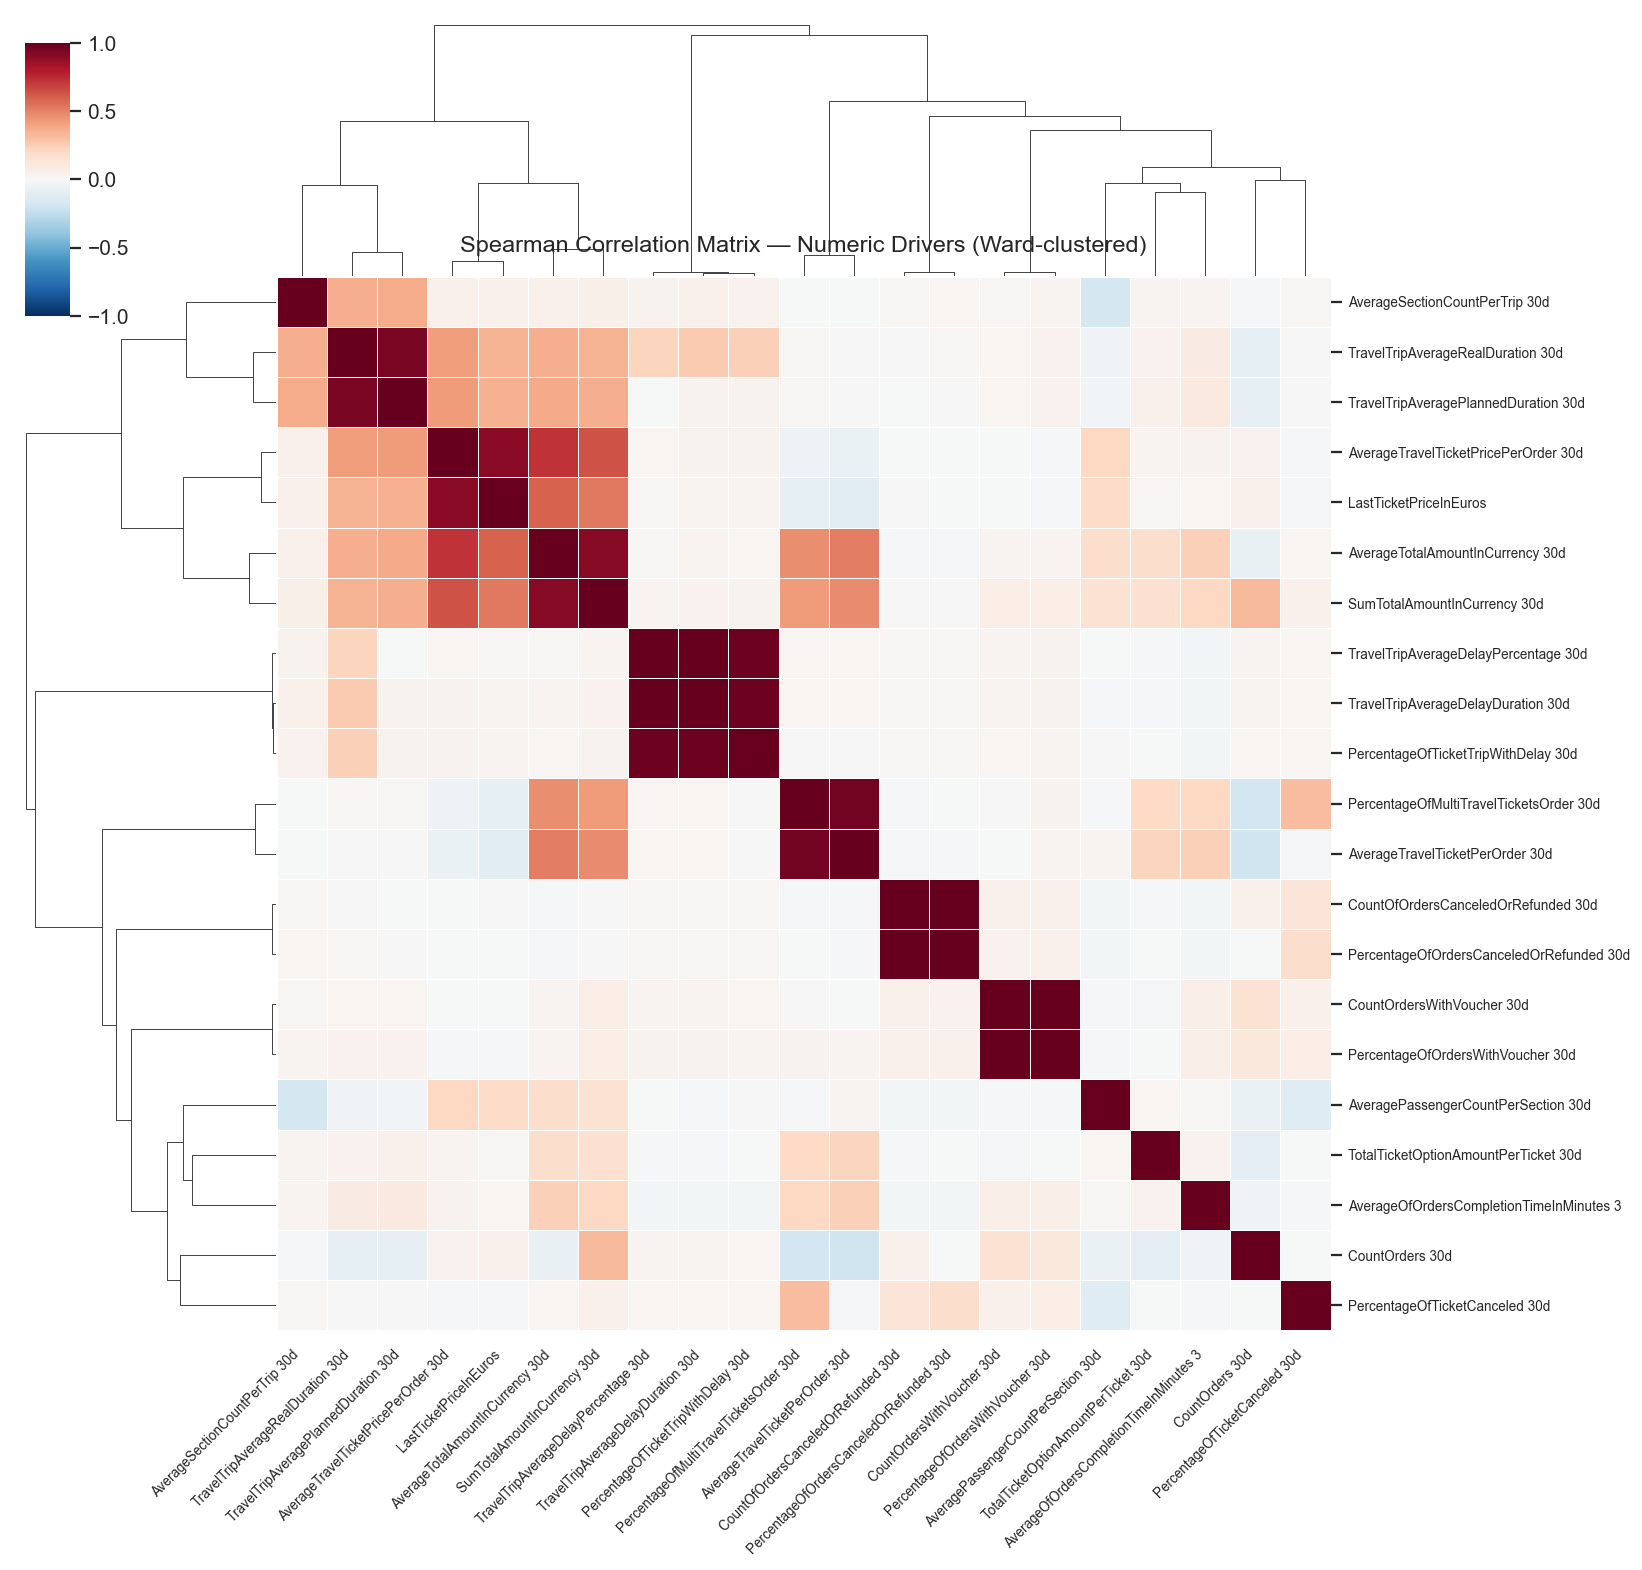

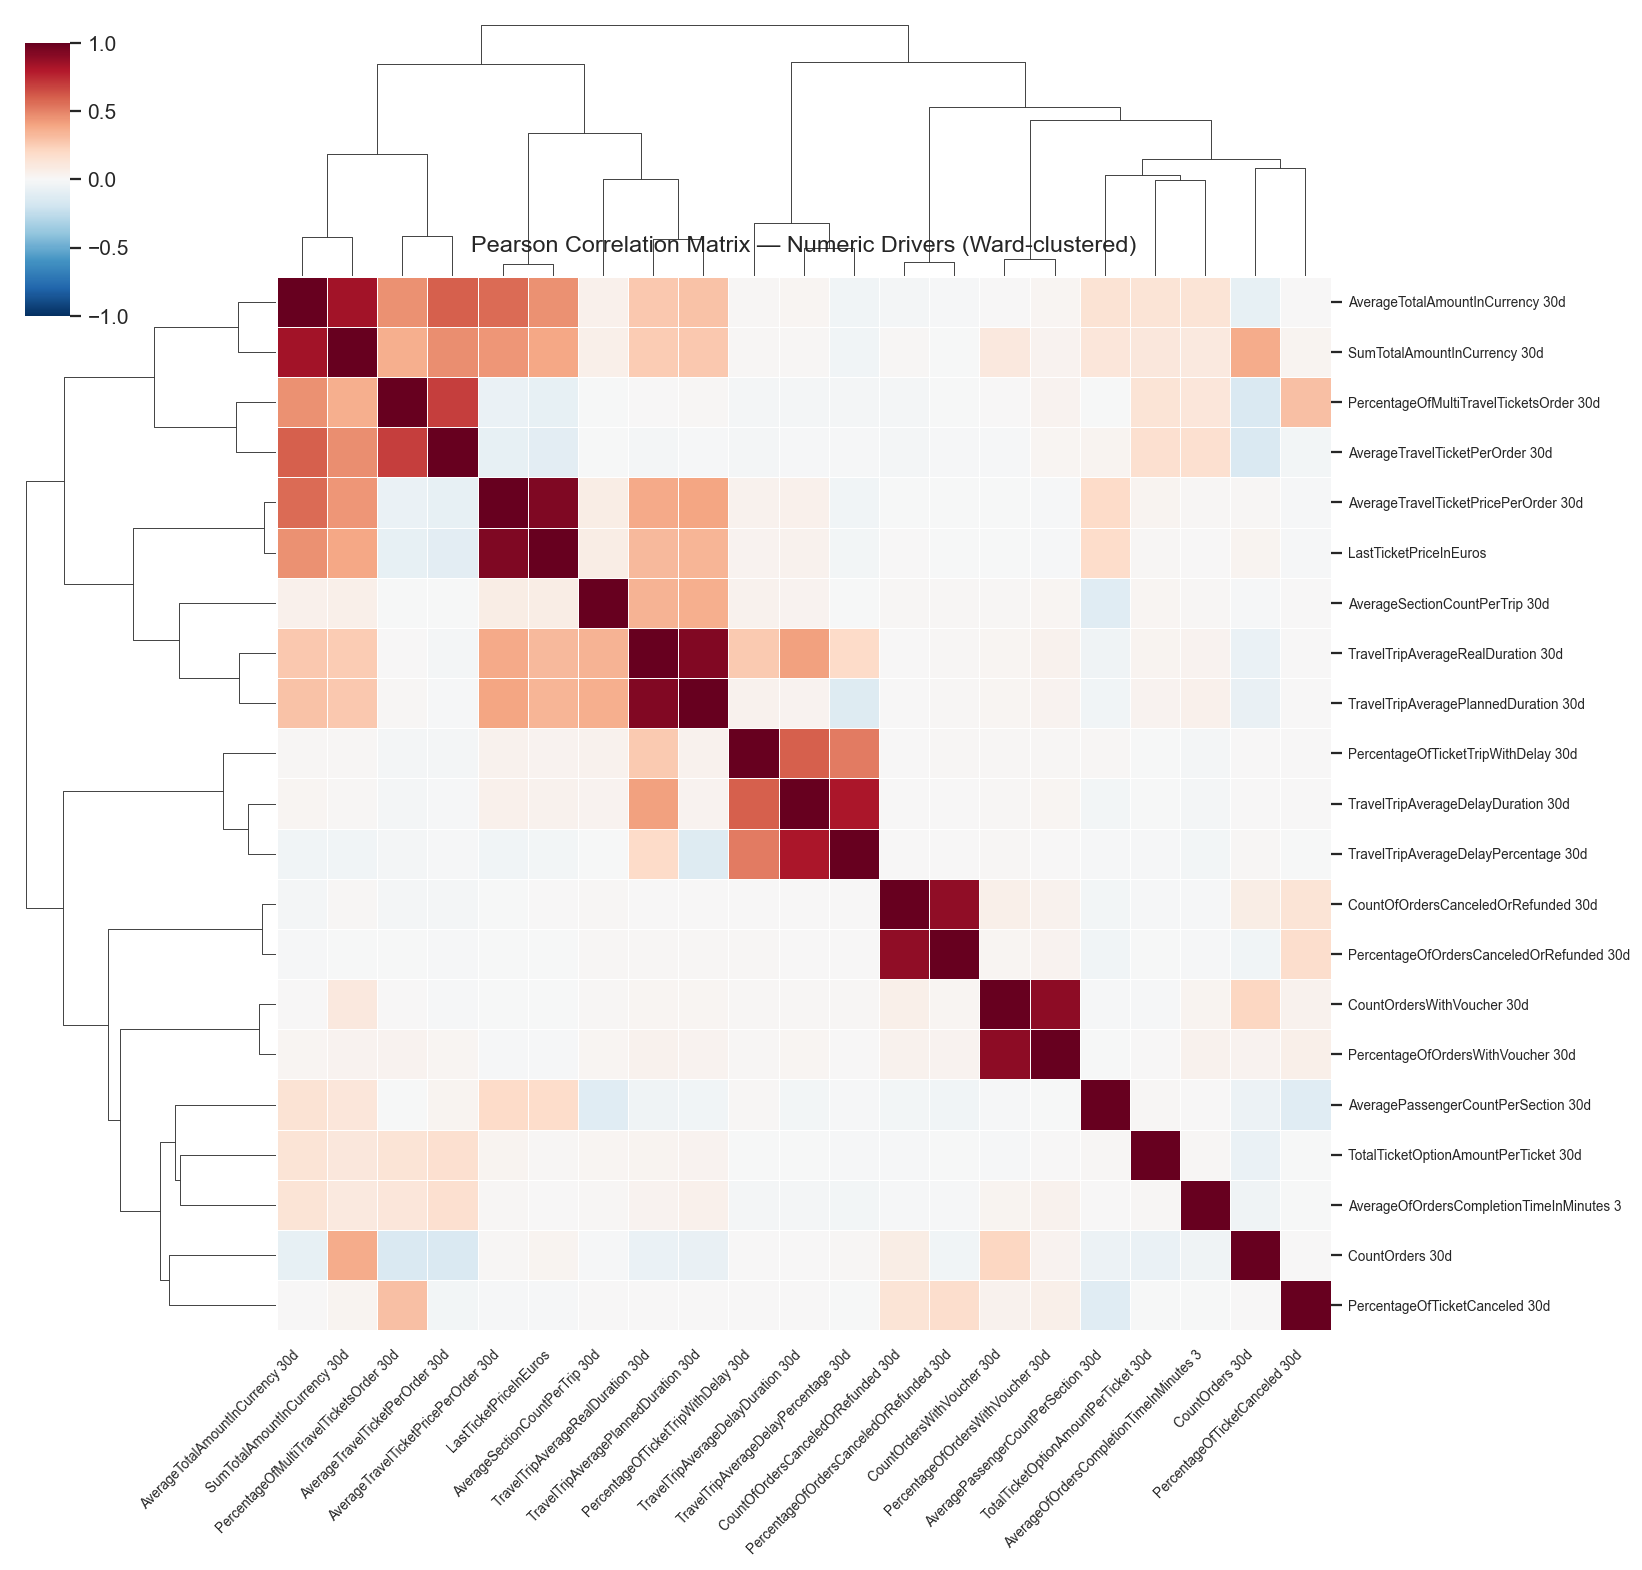


Spearman — high-correlation pairs (|ρ| > 0.85): 9 found
  Feature A                              Feature B                                   ρ
  --------------------------------------------------------------------------------------
  CountOfOrdersCanceledOrRefunded 30d    PercentageOfOrdersCanceledOrRefunded 30d +1.000
  CountOrdersWithVoucher 30d             PercentageOfOrdersWithVoucher 30d      +1.000
  TravelTripAverageDelayDuration 30d     TravelTripAverageDelayPercentage 30d   +0.996
  TravelTripAverageDelayDuration 30d     PercentageOfTicketTripWithDelay 30d    +0.980
  TravelTripAverageDelayPercentage 30d   PercentageOfTicketTripWithDelay 30d    +0.979
  PercentageOfMultiTravelTicketsOrder 30d AverageTravelTicketPerOrder 30d        +0.965
  TravelTripAverageRealDuration 30d      TravelTripAveragePlannedDuration 30d   +0.949
  AverageTotalAmountInCurrency 30d       SumTotalAmountInCurrency 30d           +0.907
  AverageTravelTicketPricePerOrder 30d   LastTicketPriceInEuros     

In [7]:
# ── Select numeric drivers that appear in the wide Train DataFrame ─────────
present_numeric = [c for c in numeric_drivers if c in wide_train.columns]

sparse_filtered = [
    c for c in present_numeric
    if null_pct.get(c, 100) <= 80
]
print(f"Numeric drivers present       : {len(present_numeric)}")
print(f"After >80% null filter        : {len(sparse_filtered)}")

numeric_pd: pd.DataFrame = (
    wide_train
    .select(sparse_filtered)
    .to_pandas()
)

# Drop zero-variance columns (undefined correlation → breaks clustermap)
zero_var_cols = [c for c in sparse_filtered if numeric_pd[c].dropna().std() == 0]
valid_numeric = [c for c in sparse_filtered if c not in set(zero_var_cols)]

if zero_var_cols:
    short_zv = [c.replace("transactional", "").replace("V0Last30d", "")[:45]
                for c in zero_var_cols]
    print(f"Dropped {len(zero_var_cols)} zero-variance column(s): {short_zv}")

numeric_pd = numeric_pd[valid_numeric]
print(f"After zero-variance filter    : {len(valid_numeric)}")

# ── Correlation matrices ───────────────────────────────────────────────────
corr_spearman: pd.DataFrame = numeric_pd.corr(method="spearman")
corr_pearson: pd.DataFrame  = numeric_pd.corr(method="pearson")

def _short_label(col: str) -> str:
    label = col.replace("transactional", "").replace("userProfile", "")
    label = label.replace("V0Last30d", " 30d").replace("V1Last30d", " 30d")
    label = label.replace("V0Last180d", " 180d").replace("V0", "")
    return label[:40]

short_labels = [_short_label(c) for c in valid_numeric]
for corr in (corr_spearman, corr_pearson):
    corr.index = short_labels
    corr.columns = short_labels

def _plot_corr_clustermap(corr_matrix: pd.DataFrame, title: str) -> None:
    n_feats = len(valid_numeric)
    fig_size = max(14, n_feats * 0.55)
    g = sns.clustermap(
        corr_matrix,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        figsize=(fig_size, fig_size),
        annot=n_feats <= 20,
        fmt=".2f",
        linewidths=0.4,
        linecolor="white",
        cbar_pos=(0.02, 0.82, 0.025, 0.15),
        method="ward",
        metric="euclidean",
    )
    g.ax_heatmap.set_title(title, fontsize=13, pad=14)
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=7.5
    )
    g.ax_heatmap.set_yticklabels(
        g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7.5
    )
    plt.show()

def _high_corr_pairs(corr_matrix: pd.DataFrame, threshold: float = 0.85) -> list[tuple]:
    pairs = []
    for i in range(len(corr_matrix)):
        for j in range(i + 1, len(corr_matrix)):
            rho = corr_matrix.iloc[i, j]
            if abs(rho) > threshold:
                pairs.append((corr_matrix.index[i], corr_matrix.columns[j], rho))
    return pairs

# ── Spearman heatmap ───────────────────────────────────────────────────────
_plot_corr_clustermap(
    corr_spearman,
    "Spearman Correlation Matrix — Numeric Drivers (Ward-clustered)",
)

# ── Pearson heatmap ────────────────────────────────────────────────────────
_plot_corr_clustermap(
    corr_pearson,
    "Pearson Correlation Matrix — Numeric Drivers (Ward-clustered)",
)

# ── High-correlation pairs for both methods ────────────────────────────────
for method_name, corr_matrix in [("Spearman", corr_spearman), ("Pearson", corr_pearson)]:
    high_corr_pairs = _high_corr_pairs(corr_matrix)
    if high_corr_pairs:
        print(f"\n{method_name} — high-correlation pairs (|ρ| > 0.85): {len(high_corr_pairs)} found")
        print(f"  {'Feature A':<38} {'Feature B':<38} {'ρ':>6}")
        print("  " + "-" * 86)
        for a, b, rho in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
            print(f"  {a:<38} {b:<38} {rho:>+6.3f}")
    else:
        print(f"\n{method_name} — no feature pairs with |ρ| > 0.85 found.")

### Business Conclusion — C. Feature Correlation & Multicollinearity

Both the Spearman and Pearson correlation matrices reveal **clusters of highly correlated numeric drivers** — particularly within the same business domain (e.g. delay duration, delay percentage, and delay bracket). Keeping redundant features inflates SHAP attributions for a single underlying behaviour and makes causal isolation harder in Phase 4.

**Implication for modelling:** Correlated driver groups **must be addressed before Phase 3** — either by dropping one representative feature per cluster or by combining them into a composite metric. This is non-negotiable if we want explainable predictions and meaningful causal estimates later.

> **Note:** Pairwise correlation only detects bivariate redundancy. Multivariate multicollinearity (e.g. a driver that is a linear combination of several others) would require regressing each driver on all remaining drivers and computing Variance Inflation Factors (VIF). That analysis is beyond the scope of this first solution but should be revisited if SHAP attributions remain unstable after bivariate deduplication.


---
## D. Covariate Shift Check — The Selection Bias Hypothesis

**What we are looking for:**

The Train set is composed exclusively of customers who *responded to an NPS survey*. Survey response is not random: frequent travellers, customers who experienced a problem, or customers in a specific age group are all systematically more likely to respond. This is the classic **Voluntary Response Bias**.

If the distribution of any feature `X` in the Train set differs significantly from its distribution in the Live population, then:

- The model trained on Train will learn a decision boundary calibrated to the *survey-responding* subpopulation.
- When we score the full 314 M-row Live population, the predicted NPS distribution will be biased.
- Causal estimates derived from the biased Train set will overstate or understate ATEs for the broader population.

**Remedy (Phase 5):** If this shift is severe, we apply **Propensity Score Weighting** when training: we train a binary classifier to predict `P(in_train | X)` and re-weight training samples by `1 / P(in_train | X)` (IPW), effectively making the Train gradient updates representative of the Live distribution.

**Current analysis:** We overlay KDE plots of two core numeric drivers for the Train set vs. the Live sample to visually detect distributional drift. We focus on:
1. `Average Delay Duration (30d)` — operational driver with direct survey-response confounder risk (delayed passengers complain more).
2. `Average Ticket Price per Order (30d)` — socioeconomic proxy that often correlates with survey response propensity.

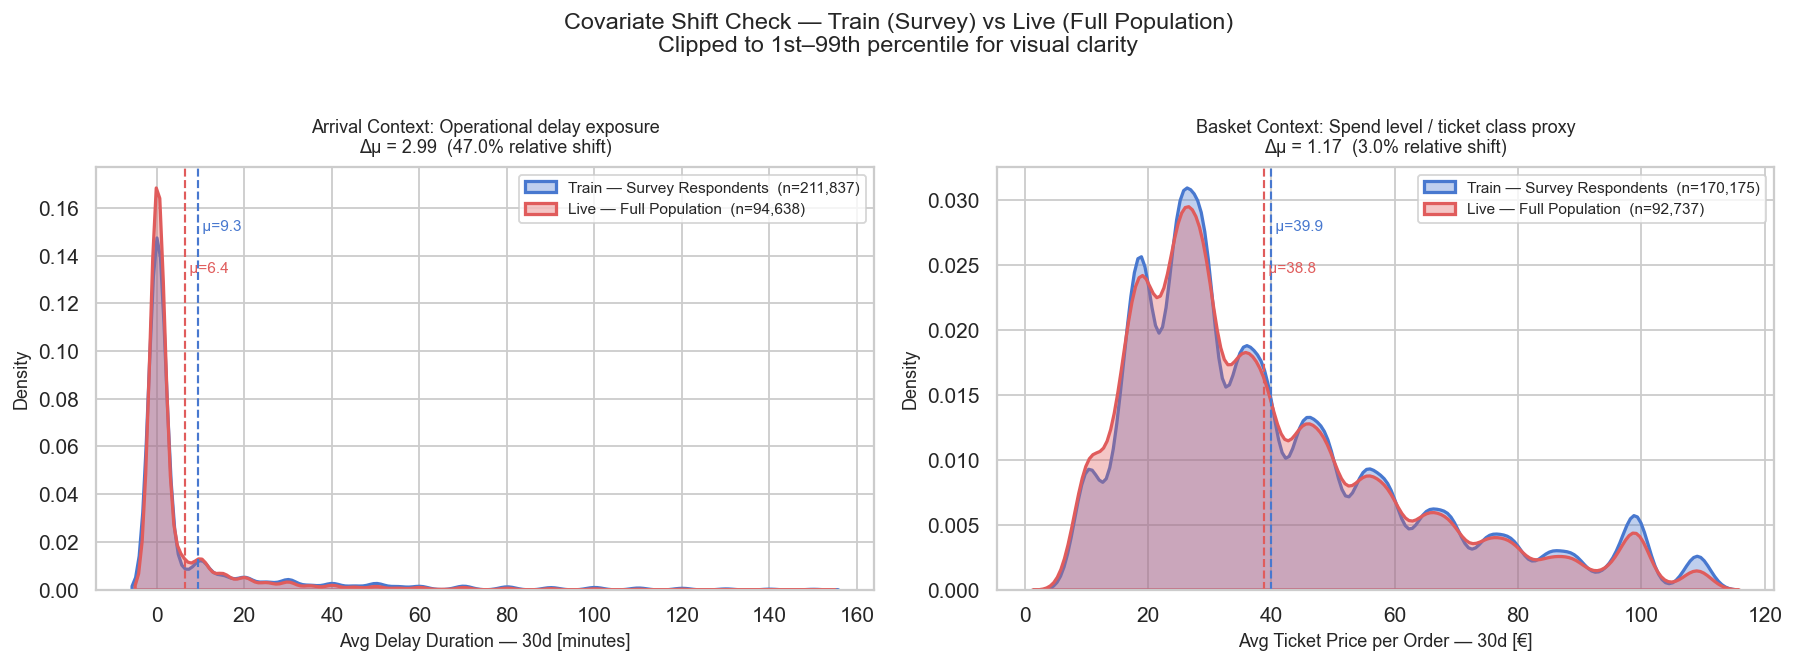


Summary Statistics Comparison

  TravelTripAverageDelayDuration
  Stat              Train         Live      Δ (abs)
  ------------------------------------------------
  mean             11.092        7.077        4.015
  median            0.000        0.000        0.000
  std              29.966       23.041        6.925
  p95              60.000       40.000       20.000

  AverageTravelTicketPricePerOrd
  Stat              Train         Live      Δ (abs)
  ------------------------------------------------
  mean             40.436       38.808        1.629
  median           35.000       32.000        3.000
  std              23.932       23.101        0.831
  p95              95.000       89.000        6.000


In [8]:
# ── Features & display config for the shift check ─────────────────────────
SHIFT_FEATURES = [
    (
        "transactionalTravelTripAverageDelayDurationV0Last30d",
        "Avg Delay Duration — 30d [minutes]",
        "Arrival Context: Operational delay exposure",
    ),
    (
        "transactionalAverageTravelTicketPricePerOrderV1Last30d",
        "Avg Ticket Price per Order — 30d [€]",
        "Basket Context: Spend level / ticket class proxy",
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (feat, x_label, subtitle) in zip(axes, SHIFT_FEATURES):
    train_vals = wide_train[feat].drop_nulls().to_numpy()
    live_vals  = wide_live[feat].drop_nulls().to_numpy() if feat in wide_live.columns else np.array([])

    if len(train_vals) == 0:
        ax.text(0.5, 0.5, "No data in Train", transform=ax.transAxes, ha="center")
        continue
    if len(live_vals) == 0:
        ax.text(0.5, 0.5, "Feature absent in Live sample", transform=ax.transAxes, ha="center")
        continue

    # Clip extreme outliers for plot readability (1st–99th percentile)
    lo = min(np.percentile(train_vals, 1), np.percentile(live_vals, 1))
    hi = max(np.percentile(train_vals, 99), np.percentile(live_vals, 99))
    train_clipped = train_vals[(train_vals >= lo) & (train_vals <= hi)]
    live_clipped  = live_vals[(live_vals >= lo)  & (live_vals <= hi)]

    sns.kdeplot(
        train_clipped,
        ax=ax,
        label=f"Train — Survey Respondents  (n={len(train_vals):,})",
        color="#4878CF",
        fill=True,
        alpha=0.35,
        linewidth=1.8,
    )
    sns.kdeplot(
        live_clipped,
        ax=ax,
        label=f"Live — Full Population  (n={len(live_vals):,})",
        color="#E05C5C",
        fill=True,
        alpha=0.35,
        linewidth=1.8,
    )

    # Annotate mean lines
    train_mean = train_clipped.mean()
    live_mean  = live_clipped.mean()
    ax.axvline(train_mean, color="#4878CF", linestyle="--", linewidth=1.2)
    ax.axvline(live_mean,  color="#E05C5C", linestyle="--", linewidth=1.2)
    ax.text(train_mean, ax.get_ylim()[1] * 0.85, f" μ={train_mean:.1f}", color="#4878CF", fontsize=8.5)
    ax.text(live_mean,  ax.get_ylim()[1] * 0.75, f" μ={live_mean:.1f}",  color="#E05C5C", fontsize=8.5)

    # Δμ annotation
    delta = abs(train_mean - live_mean)
    rel_delta = delta / (abs(live_mean) + 1e-9) * 100
    ax.set_title(
        f"{subtitle}\nΔμ = {delta:.2f}  ({rel_delta:.1f}% relative shift)",
        fontsize=10, pad=8,
    )
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=8.5, loc="upper right")

plt.suptitle(
    "Covariate Shift Check — Train (Survey) vs Live (Full Population)\n"
    "Clipped to 1st–99th percentile for visual clarity",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Population-level summary statistics for the two features ──────────────
print("\nSummary Statistics Comparison")
print("=" * 72)
for feat, x_label, _ in SHIFT_FEATURES:
    t = wide_train[feat].drop_nulls().to_numpy() if feat in wide_train.columns else np.array([])
    l = wide_live[feat].drop_nulls().to_numpy()  if feat in wide_live.columns  else np.array([])
    short = feat.replace("transactional", "").replace("V0Last30d", "").replace("V1Last30d", "")[:30]
    print(f"\n  {short}")
    print(f"  {'Stat':<10} {'Train':>12} {'Live':>12} {'Δ (abs)':>12}")
    print(f"  {'-'*48}")
    for stat, tf, lf in [
        ("mean",   np.mean(t)   if len(t) else np.nan, np.mean(l)   if len(l) else np.nan),
        ("median", np.median(t) if len(t) else np.nan, np.median(l) if len(l) else np.nan),
        ("std",    np.std(t)    if len(t) else np.nan, np.std(l)    if len(l) else np.nan),
        ("p95",    np.percentile(t, 95) if len(t) else np.nan, np.percentile(l, 95) if len(l) else np.nan),
    ]:
        print(f"  {stat:<10} {tf:>12.3f} {lf:>12.3f} {abs(tf - lf):>12.3f}")
print("=" * 72)

### Business Conclusion — D. Covariate Shift

We compared the distributions of two core numeric drivers — **Average Delay Duration (30d)** and **Average Ticket Price per Order (30d)** — between the Train set (survey respondents) and a Live sample (full population). If a systematic distributional gap existed, it would indicate **selection bias**: survey respondents are not representative of the broader customer base, and model predictions scored on the Live set would require **Importance Reweighting** (training samples weighted by the inverse of their propensity to appear in the Train set).

**Finding:** The KDE overlays show **no meaningful covariate shift** for either driver — the Train and Live distributions overlap closely, and mean shifts are negligible. **Importance Reweighting is not required** for Phase 3 training on these features. We should still monitor additional drivers before finalising the Live scoring pipeline, but the selection-bias hypothesis is not supported by the evidence here.


---
## Phase 2, Part 1: Core Feature Transformations

Our modelling stack is LightGBM. LightGBM ships with two algorithms that make most classical preprocessing unnecessary:

1. **Native NaN routing** — at every split, the missing branch is learned from the data, so we can leave nulls untouched on all numeric drivers.
2. **Fisher categorical partitioning** — for `pl.Categorical` columns passed via `categorical_feature=`, LightGBM finds the optimal many-to-many split of category levels rather than treating them as ordinal codes.

The only drivers that *do* require pre-processing are the three **multi-categorical** option-combination columns (`transactionalLastOptionCombinationPer*V0`), which encode a set of tokens per customer using `||` as a separator. We transform these with a bounded **top-5 CountVectorizer** so the feature space stays tight (at most 15 new binary columns) and the long tail of rare token combinations does not balloon LightGBM's split-finding work.


In [9]:
from src.features import MultiCategoricalEncoder

# Programmatically extract multi-categorical columns from the definitions map
multi_cat_cols: list[str] = [
    key for key, dtype in definitions_map.items()
    if dtype == pl.String and key in wide_train.columns
]
print(f"Multi-categorical drivers to encode: {len(multi_cat_cols)}")
for col in multi_cat_cols:
    print(f"  • {col}")

shape_before = wide_train.shape

encoder = MultiCategoricalEncoder(columns=multi_cat_cols, max_features=5)
wide_train_fe: pl.DataFrame = encoder.fit_transform(wide_train)

print(f"\nShape before transformation : {shape_before}")
print(f"Shape after  transformation : {wide_train_fe.shape}")
print(f"Net column delta            : {wide_train_fe.shape[1] - shape_before[1]:+d}")

print("\nGenerated indicator columns per source driver:")
for src_col, generated in encoder.output_columns.items():
    print(f"\n  {src_col}")
    for new_col in generated:
        print(f"    → {new_col}")


Multi-categorical drivers to encode: 3
  • transactionalLastOptionCombinationPerTicketNoDelayV0
  • transactionalLastOptionCombinationPerOrderV0
  • transactionalLastOptionCombinationPerTicketV0

Shape before transformation : (227400, 68)
Shape after  transformation : (227400, 77)
Net column delta            : +9

Generated indicator columns per source driver:

  transactionalLastOptionCombinationPerTicketNoDelayV0
    → transactionalLastOptionCombinationPerTicketNoDelayV0__LUGGAGE
    → transactionalLastOptionCombinationPerTicketNoDelayV0__NO_OPTIONS
    → transactionalLastOptionCombinationPerTicketNoDelayV0__SEAT
    → transactionalLastOptionCombinationPerTicketNoDelayV0__STROLLER
    → transactionalLastOptionCombinationPerTicketNoDelayV0__WIFI_ENTERTAINMENT

  transactionalLastOptionCombinationPerOrderV0
    → transactionalLastOptionCombinationPerOrderV0__FLEX
    → transactionalLastOptionCombinationPerOrderV0__NO_OPTIONS

  transactionalLastOptionCombinationPerTicketV0
    → transa

> **Note:** Continuous numerics and standard categoricals are left intentionally raw to leverage LightGBM's native NaN routing and Fisher categorical partitioning algorithms.


In [10]:
preview_cols = [c for cols in encoder.output_columns.values() for c in cols]
wide_train_fe.select(preview_cols).head(5)


transactionalLastOptionCombinationPerTicketNoDelayV0__LUGGAGE,transactionalLastOptionCombinationPerTicketNoDelayV0__NO_OPTIONS,transactionalLastOptionCombinationPerTicketNoDelayV0__SEAT,transactionalLastOptionCombinationPerTicketNoDelayV0__STROLLER,transactionalLastOptionCombinationPerTicketNoDelayV0__WIFI_ENTERTAINMENT,transactionalLastOptionCombinationPerOrderV0__FLEX,transactionalLastOptionCombinationPerOrderV0__NO_OPTIONS,transactionalLastOptionCombinationPerTicketV0__LUGGAGE,transactionalLastOptionCombinationPerTicketV0__NO_OPTIONS,transactionalLastOptionCombinationPerTicketV0__SEAT,transactionalLastOptionCombinationPerTicketV0__STROLLER,transactionalLastOptionCombinationPerTicketV0__WIFI_ENTERTAINMENT
u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
0,0,1,0,0,1,0,0,0,1,0,0
0,0,1,0,0,0,1,0,0,1,0,0
1,0,1,0,1,0,1,1,0,1,0,1
1,0,0,0,0,0,1,1,0,0,0,0
0,0,1,0,0,0,1,0,0,1,0,0


---
## Phase 2, Part 2: Collinearity & Causal Clean-up

If two features encode the same underlying concept, LightGBM **randomly distributes split importance between them** — which destroys SHAP attribution stability and any downstream causal Average Treatment Effect we compute in Phase 4. We therefore run two complementary filters before training:

1. **Semantic redundancy** — a manual audit identified three discretised categorical drivers (`DelayDurationBracket`, `LastTicketPricePosition`, `AverageSectionOccupancyLevel`) that are bracketised versions of continuous numeric drivers already in the matrix. The categorical brackets are dropped; the continuous numerics carry the full signal.
2. **Numeric collinearity** — for the remaining numeric drivers we compute the absolute **Spearman** correlation matrix (Spearman is mandated to capture non-linear monotonic redundancies and to be robust against the heavy operational outliers in the rail data). For every pair with `|ρ| > 0.85`, the column with the **higher null rate** is dropped — keeping the variant that carries the most signal.


In [11]:
from src.features import semantic_redundancy_dropper, numeric_collinearity_filter

shape_p1 = wide_train_fe.shape
print(f"Shape after Phase 2 Part 1 (encoding): {shape_p1}\n")

wide_train_fe = semantic_redundancy_dropper(wide_train_fe)
shape_after_semantic = wide_train_fe.shape
print(f"\nShape after semantic redundancy drop : {shape_after_semantic}")
print(f"  Δ columns                          : {shape_after_semantic[1] - shape_p1[1]:+d}\n")


Shape after Phase 2 Part 1 (encoding): (227400, 77)

Semantic redundancy filter — dropped 3 categorical bracket(s) in favour of their continuous numeric counterparts:
  • transactionalTravelTripDelayDurationBracketV0Last30d
      kept instead → transactionalTravelTripAverageDelayDurationV0Last30d
  • transactionalLastTicketPricePositionV0
      kept instead → transactionalLastTicketPriceInEurosV0
  • transactionalAverageSectionOccupancyLevelV0Last30d
      kept instead → transactionalAveragePassengerCountPerSectionV0Last30d

Shape after semantic redundancy drop : (227400, 74)
  Δ columns                          : -3



In [12]:
priority_levers = [
    "transactionalTravelTripAverageDelayDurationV0Last30d",
    "transactionalTravelTripAverageRealDurationV0Last30d",
]

wide_train_fe = numeric_collinearity_filter(
    wide_train_fe,
    threshold=0.85,
    priority_features=priority_levers,
)
shape_final = wide_train_fe.shape

print(
    f"\n{'=' * 64}\n"
    f"Final Train shape after Phase 2 feature engineering: {shape_final}\n"
    f"  Columns retained vs post-encoding  : {shape_final[1]} / {shape_p1[1]} "
    f"({(shape_final[1] / shape_p1[1] - 1) * 100:+.1f}%)\n"
    f"  Rows retained                      : {shape_final[0]:,}\n"
    f"{'=' * 64}"
)


Numeric collinearity filter (Spearman |ρ| > 0.85) — dropped 15 column(s) of 42 (priority protected: 2):
  • Dropped transactionalLastOptionCombinationPerTicketV0__LUGGAGE
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicketNoDelayV0__LUGGAGE  (nulls: 0.0% vs 0.0% kept)
  • Dropped transactionalLastOptionCombinationPerTicketV0__NO_OPTIONS
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicketNoDelayV0__NO_OPTIONS  (nulls: 0.0% vs 0.0% kept)
  • Dropped transactionalLastOptionCombinationPerTicketV0__SEAT
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicketNoDelayV0__SEAT  (nulls: 0.0% vs 0.0% kept)
  • Dropped transactionalLastOptionCombinationPerTicketV0__STROLLER
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicketNoDelayV0__STROLLER  (nulls: 0.0% vs 0.0% kept)
  • Dropped transactionalLastOptionCombinationPerTicketV0__WIFI_ENTERTAINMENT
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicket

### Phase 2 — Conclusion

Feature engineering is complete. The pipeline combined three deliberately complementary mechanisms:

1. **Bounded `CountVectorizer` (Part 1)** — capped the multi-categorical option-combination expansion to 5 indicator columns per source driver, preventing a long-tail explosion of rare option combinations.
2. **Manual semantic audit (Part 2)** — removed three pre-known categorical / numeric duplications that no statistical filter could justify on its own. These were domain-knowledge decisions, not data-driven ones.
3. **Dynamic Spearman collinearity filter (Part 2)** — caught the data-driven redundancies (window aliases, percentage/count pairs, post-encoding indicator anti-correlations) using a rank-based metric that is robust to outliers and non-linear monotonic relationships.

Together this ensures that **no two columns in the final feature matrix encode the same latent concept**. SHAP attributions in Phase 3 will be unambiguous, and the causal estimands in Phase 4 will be defensible — each retained driver represents a *distinct lever* that the business can credibly act on.
